In [1]:
from datasets import load_dataset, load_from_disk
from typing import List, Tuple, Union, List
import gc
import json
import gc
import pandas as pd

BASE_PATH = "../../data/qa_datasets/"
DATASET_DIR_NAME = "musique_validation"

SAVE_DATASET_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/original"
SAVE_TMP_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/tmp_musique_cntx.csv" 
SAVE_CONTEXTS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/relevant_contexts.csv"
SAVE_QA_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/qa_pairs.csv"
SAVE_STATS_PATH = f"{BASE_PATH}/{DATASET_DIR_NAME}/stats.json"

DOC_MAX_LEN = 1024
DOC_MIN_LEN = 64
MAX_QA_PAIRS = 2000
NOISE_DOCUMENTS_AMOUNT = 2000

/home/dzigen/Desktop/Projects/PersonalAI/.pai_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from utils import preprocess_documents, plot_textlen_distribution, \
    preprocess_qapairs, select_noise_documents, calculate_dataset_stats, \
        check_dataset_consistency, calculate_original_dataset_stats

In [ ]:
original_dataset = load_dataset("dgslibisey/MuSiQue", split="validation") # 6k
original_dataset.save_to_disk(SAVE_DATASET_PATH)

Saving the dataset (1/1 shards): 100%|██████████| 2417/2417 [00:00<00:00, 100686.62 examples/s]


In [ ]:
original_dataset

Dataset({
    features: ['id', 'paragraphs', 'question', 'question_decomposition', 'answer', 'answer_aliases', 'answerable'],
    num_rows: 2417
})

In [14]:
original_dataset

Dataset({
    features: ['id', 'paragraphs', 'question', 'question_decomposition', 'answer', 'answer_aliases', 'answerable'],
    num_rows: 2417
})

In [ ]:
original_dataset['paragraphs'][0]

[{'idx': 0,
  'title': "Grant's First Stand",
  'paragraph_text': 'Grant\'s First Stand is the debut album by American jazz guitarist Grant Green featuring performances by Green recorded and released on the Blue Note label in 1961. Earlier recordings made by Green for Blue Note were released as "First Session" in 2001.',
  'is_supporting': False},
 {'idx': 1,
  'title': 'List of show business families',
  'paragraph_text': 'Actress / director / singer Phylicia Rashād is the older sister of performer Debbie Allen, who is married to former NBA basketball player, Norm Nixon. Phylicia Rashād is the former spouse of both Victor Willis, former lead singer of the group Village People, and former NFL football player turned sportscaster, Ahmad Rashād. Phylicia and Ahmad Rashād are the parents of actress Condola Rashād.',
  'is_supporting': False},
 {'idx': 2,
  'title': 'Green',
  'paragraph_text': 'For the ancient Egyptians, green had very positive associations. The hieroglyph for green repres

In [3]:
original_dataset = load_from_disk(SAVE_DATASET_PATH)

In [4]:
def get_question_documents(dataset: object, idx: int) -> List[Tuple[Union[None,str], str]]: 
    documents = []
    for paragraph_info in dataset['paragraphs'][idx]:
        documents.append((paragraph_info['title'], paragraph_info['paragraph_text']))
    return documents

def get_dataset_len(dataset: object) -> int:
    return len(dataset)

def get_qa_info(dataset: object, idx: int) -> Tuple[str, str, str, List[Tuple[Union[None, str], str]]]:
    question_type = None
    question, answer = dataset['question'][idx], dataset['answer'][idx]
    relevant_documents = []
    for paragraph_info in dataset['paragraphs'][idx]:
        if paragraph_info['is_supporting']:
            relevant_documents.append((paragraph_info['title'], paragraph_info['paragraph_text']))

    return question, question_type, answer, relevant_documents

In [5]:
CUSTOM_FUNCS = {
    'get_question_documents': get_question_documents,
    'get_dataset_len': get_dataset_len,
    'get_qa_info': get_qa_info
}

In [6]:
calculate_original_dataset_stats(original_dataset, CUSTOM_FUNCS)

100%|██████████| 2417/2417 [00:08<00:00, 297.96it/s]

Questions (with duplications):
{'median': 94.0, 'mean': 101.51345, 'std': 38.90756, 'min': 26, 'max': 275, 'count': 2417}
Questions (w/o duplications):
{'median': 94.0, 'mean': 101.5369, 'std': 38.92281, 'min': 26, 'max': 275, 'count': 2412}
Answers (with duplications):
{'median': 14.0, 'mean': 16.964, 'std': 12.62288, 'min': 1, 'max': 75, 'count': 2417}
Answers (w/o duplications):
{'median': 14.0, 'mean': 16.71816, 'std': 11.88332, 'min': 1, 'max': 75, 'count': 738}
Documents (with duplications):  48315
Documents (w/o duplications):  21100
Documents per questions: 
{'median': 2.0, 'mean': 2.64957, 'std': 0.75017, 'min': 2, 'max': 4, 'count': 2417}


### Preprocessing documents

In [7]:
accepted_documents_df = preprocess_documents(
    original_dataset, DOC_MIN_LEN, DOC_MAX_LEN, CUSTOM_FUNCS)

100%|██████████| 2417/2417 [00:02<00:00, 1005.07it/s]


In [ ]:
accepted_documents_df.to_csv(SAVE_TMP_CONTEXTS_PATH, index=False)

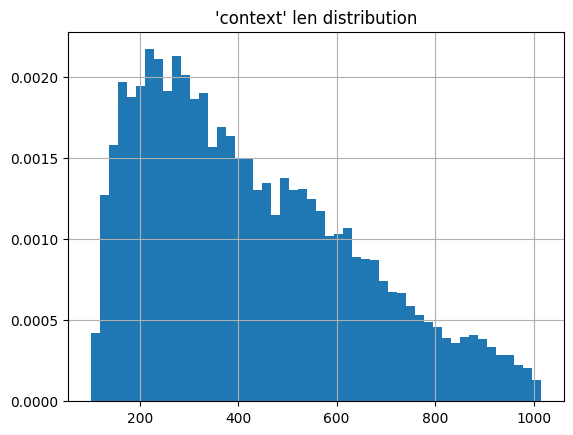

In [8]:
plot_textlen_distribution(accepted_documents_df, 'context')

In [9]:
accepted_documents_df.head()

,title,context,hash,original_qaidx
0,Grant's First Stand,Grant's First Stand is the debut album by Amer...,042d5f9b5733218549c66c097bb025b7,0
1,List of show business families,Actress / director / singer Phylicia Rashād is...,cbe6d768560c6d0a6da06c27a81269b2,0
2,Green,"For the ancient Egyptians, green had very posi...",77e2b88fddf76766b939268a0030d514,0
3,"Green Lake (Chisago City, Minnesota)","Green Lake is a lake in Chisago City, Minnesot...",e6b7b4be8d6b67edef2331851ea8b402,0
4,Musty Rusty,Musty Rusty is an album by jazz saxophonist Lo...,4929afb701f4587cfecce192e73aa031,0


In [10]:
accepted_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19867 entries, 0 to 19866
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           19867 non-null  object
 1   context         19867 non-null  object
 2   hash            19867 non-null  object
 3   original_qaidx  19867 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 621.0+ KB


In [11]:
accepted_documents_df.shape

(19867, 4)

### Preprocessing QA pairs

In [12]:
qapairs_df, relevant_documents_df = preprocess_qapairs(
    original_dataset, accepted_documents_df, MAX_QA_PAIRS, CUSTOM_FUNCS)

100%|██████████| 2417/2417 [00:05<00:00, 412.66it/s]


In [ ]:
qapairs_df.to_csv(SAVE_QA_PATH, index=False)

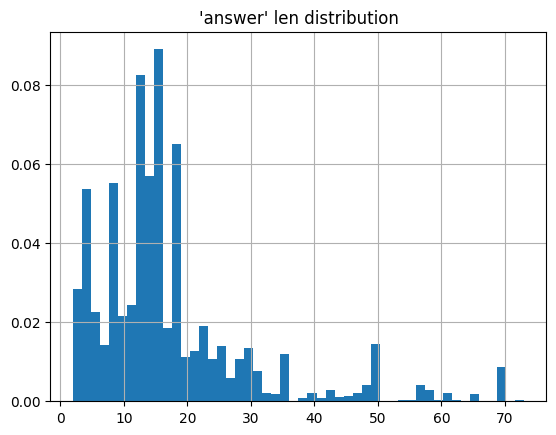

In [13]:
plot_textlen_distribution(qapairs_df, 'answer')

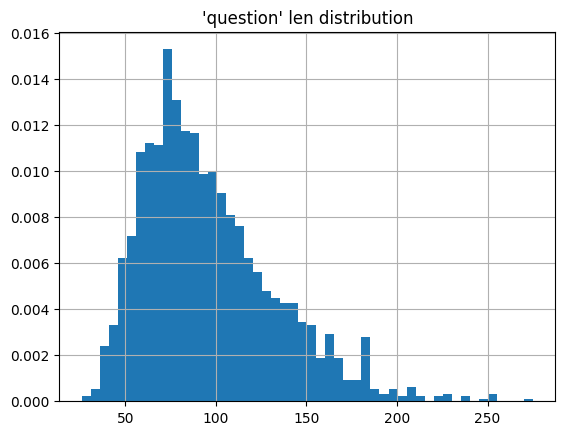

In [14]:
plot_textlen_distribution(qapairs_df, 'question')

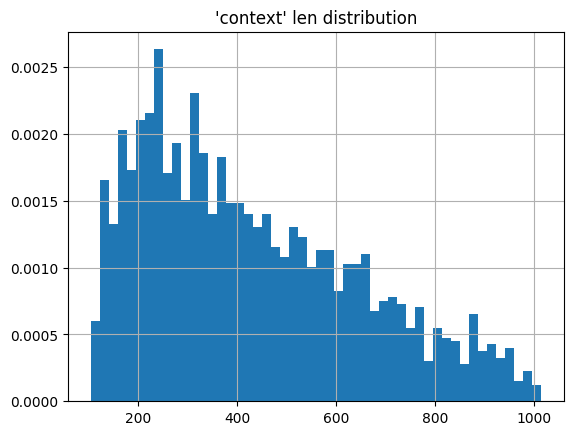

In [15]:
plot_textlen_distribution(relevant_documents_df, 'context')

In [16]:
qapairs_df

,question,type,answer,cntx_ids,qa_idx,original_qaidx
0,Who is the spouse of the Green performer?,None,Miquette Giraudy,"[0, 1]",0,0
1,Who founded the company that distributed the f...,None,Mike Medavoy,"[2, 3]",1,1
2,What administrative territorial entity is the ...,None,Tamaulipas,"[4, 5]",2,2
3,Where is Ulrich Walter's employer headquartered?,None,Cologne,"[6, 7]",3,3
4,Which company owns the manufacturer of Learjet...,None,Bombardier Inc.,"[8, 9]",4,4
...,...,...,...,...,...,...
1926,What was the first OS to support Hyper-V from ...,None,Windows 8,"[2162, 2178, 2102]",1926,2412
1927,How were those people defied by the use of new...,None,The dynasty regrouped and defeated the Portuguese,"[1836, 1843, 2179]",1927,2413
1928,Who sent naval ships to the body of water that...,None,Caesar,"[2180, 2181, 2182]",1928,2414
1929,How were the people that the Somali Muslim Aju...,None,The dynasty regrouped and defeated the Portuguese,"[1843, 2183, 1836]",1929,2415


In [17]:
qapairs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1931 entries, 0 to 1930
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   question        1931 non-null   object
 1   type            0 non-null      object
 2   answer          1931 non-null   object
 3   cntx_ids        1931 non-null   object
 4   qa_idx          1931 non-null   int64 
 5   original_qaidx  1931 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 90.6+ KB


In [18]:
qapairs_df.shape

(1931, 6)

In [19]:
relevant_documents_df

,title,context,cntx_idx,hash
0,Miquette Giraudy,"Miquette Giraudy (born 9 February 1953, Nice, ...",0,19e873ee12eeceb17a513ab97b4f8a40
1,Green (Steve Hillage album),Green is the fourth studio album by British pr...,1,95c1b22c6221992201c81ada94c7bece
2,Mike Medavoy,"Morris Mike Medavoy (born January 21, 1941) is...",2,e5d1c2e188ce2fd916a82d1979804ba6
3,UHF (film),Yankovic and Levey wrote the film after Yankov...,3,694bec4223328f4f24d12a97e6571969
4,Nuevo Laredo Municipality,The Municipality of Nuevo Laredo is located in...,4,d3414ebc09b73d51a3082c6e54e4a733
...,...,...,...,...
2180,Roman Republic,After having declined in size following the su...,2180,ac04cd23baa82a296f723a46bfa52431
2181,North Sea,The North Sea is bounded by the Orkney Islands...,2181,955eed5a94fece744aeb11df59250fe9
2182,Rhine,"The Rhine (Romansh: Rein, German: Rhein, Frenc...",2182,0961efa2681801039d05f25b5b9d704c
2183,Star Cola,Star Cola () is a cola drink produced in Myanm...,2183,0be9d18434c1204424171a978afff2f2


In [20]:
relevant_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2185 entries, 0 to 2184
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     2185 non-null   object
 1   context   2185 non-null   object
 2   cntx_idx  2185 non-null   int64 
 3   hash      2185 non-null   object
dtypes: int64(1), object(3)
memory usage: 68.4+ KB


In [21]:
relevant_documents_df.shape

(2185, 4)

### Expanding relevant documents dataframe by noise documents

In [22]:
DOCIDX_OFFSET = max(relevant_documents_df['cntx_idx'].tolist()) + 1
print(DOCIDX_OFFSET)
noise_documents_df = select_noise_documents(
    relevant_documents_df, accepted_documents_df, 
    NOISE_DOCUMENTS_AMOUNT, DOCIDX_OFFSET, CUSTOM_FUNCS)

expanded_relevant_documents_df = pd.concat([relevant_documents_df, noise_documents_df], ignore_index=True)

2185


2000it [00:02, 703.96it/s]


In [ ]:
expanded_relevant_documents_df.to_csv(SAVE_CONTEXTS_PATH, index=False)

In [23]:
noise_documents_df

,title,context,cntx_idx,hash
0,Pierre Teilhard de Chardin,Pierre Teilhard de Chardin ( (); 1 May 1881 – ...,2185,3128cb1e1830211ecbb2719707a104e4
1,Aikenhead's Hardware,Aikenhead's Hardware was a chain of Canadian h...,2186,4cf1c5c96493e6c397af87f5cbc7f9bb
2,Dog,Purebred dogs of one breed are genetically dis...,2187,264fe7df20266c1e6285b7bf5465a616
3,General Satellite,Tricolor TV is the Russia’s largest satellite ...,2188,f6320a10862233124f7b24271bb7d752
4,Czech Academy of Sciences,The Head Office of the Academy and forty resea...,2189,e03c806e66e2052b2b2d8b86adf88416
...,...,...,...,...
1995,Route 888 (Israel),Route 888 is a north-south regional highway in...,4180,d69440461fd132ef37e67b6a8eea87f2
1996,Washington University in St. Louis,Washington University's North Campus and West ...,4181,331615aebc5221570c66f68a122731c2
1997,National Register of Historic Places listings ...,This list includes properties and districts li...,4182,554114a9b66f56319057ef701eb801ee
1998,Father's Day,Father's Day is a celebration honoring fathers...,4183,489082ae45eb813ee36fb4c3af8ffa40


In [24]:
noise_documents_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     2000 non-null   object
 1   context   2000 non-null   object
 2   cntx_idx  2000 non-null   int64 
 3   hash      2000 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB


In [25]:
noise_documents_df.shape

(2000, 4)

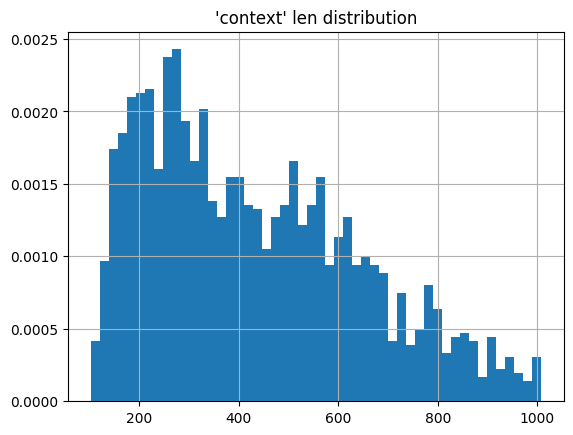

In [26]:
plot_textlen_distribution(noise_documents_df, 'context')

In [27]:
expanded_relevant_documents_df

,title,context,cntx_idx,hash
0,Miquette Giraudy,"Miquette Giraudy (born 9 February 1953, Nice, ...",0,19e873ee12eeceb17a513ab97b4f8a40
1,Green (Steve Hillage album),Green is the fourth studio album by British pr...,1,95c1b22c6221992201c81ada94c7bece
2,Mike Medavoy,"Morris Mike Medavoy (born January 21, 1941) is...",2,e5d1c2e188ce2fd916a82d1979804ba6
3,UHF (film),Yankovic and Levey wrote the film after Yankov...,3,694bec4223328f4f24d12a97e6571969
4,Nuevo Laredo Municipality,The Municipality of Nuevo Laredo is located in...,4,d3414ebc09b73d51a3082c6e54e4a733
...,...,...,...,...
4180,Route 888 (Israel),Route 888 is a north-south regional highway in...,4180,d69440461fd132ef37e67b6a8eea87f2
4181,Washington University in St. Louis,Washington University's North Campus and West ...,4181,331615aebc5221570c66f68a122731c2
4182,National Register of Historic Places listings ...,This list includes properties and districts li...,4182,554114a9b66f56319057ef701eb801ee
4183,Father's Day,Father's Day is a celebration honoring fathers...,4183,489082ae45eb813ee36fb4c3af8ffa40


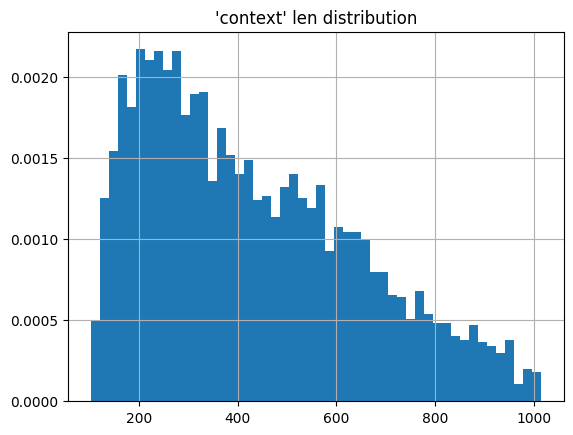

In [28]:
plot_textlen_distribution(expanded_relevant_documents_df, 'context')

### Calculating statistics

In [29]:
processed_dataset_stats = calculate_dataset_stats(qapairs_df, expanded_relevant_documents_df)
processed_dataset_stats['NOISE_DOCUMENTS_AMOUNT'] = NOISE_DOCUMENTS_AMOUNT

In [ ]:
with open(SAVE_STATS_PATH, 'w', encoding='utf-8') as fd:
    json.dump(processed_dataset_stats, fd, indent=1, ensure_ascii=False)

In [30]:
check_dataset_consistency(original_dataset, qapairs_df, expanded_relevant_documents_df, CUSTOM_FUNCS)

100%|██████████| 1931/1931 [00:06<00:00, 283.11it/s]


True

In [31]:
processed_dataset_stats

{'contexts_amount': 4185,
 'contexts_len': {'median': 388.0,
  'mean': 430.2098,
  'std': 217.36497,
  'min': 102,
  'max': 1016,
  'count': 4185},
 'qa_pairs_amount': 1931,
 'answers_len': {'median': 14.0,
  'mean': 17.20663,
  'std': 12.72944,
  'min': 2,
  'max': 73,
  'count': 1931},
 'questions_len': {'median': 89.0,
  'mean': 95.98654,
  'std': 36.92796,
  'min': 26,
  'max': 275,
  'count': 1931},
 'rel_contexts_per_question': {'median': 2.0,
  'mean': 2.58778,
  'std': 0.7303,
  'min': 2,
  'max': 4,
  'count': 1931},
 'NOISE_DOCUMENTS_AMOUNT': 2000}